# Proyecto 2 Segmentación de Estudiantes en Redes Sociales con K-Means
**Unidad 4**

Lozano Orona Samuel

Quiñones Hernández Mario Alberto  

**1. Cargar librerías y dataset**

In [1]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configuración general
import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

In [2]:
# Cargar el dataset
# Asegúrate de subir el archivo CSV a Google Colab antes de ejecutar esta celda
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/1vEYVdQRliz-xTPq_F6DrUvnlY97_eSqj/view?usp=sharing

file_id = "1vEYVdQRliz-xTPq_F6DrUvnlY97_eSqj"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
estudiantes=pd.read_csv(url)
estudiantes.head()

Mounted at /content/drive


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


**2. Exploración inicial del dataset**

In [3]:
# Tamaño del dataset
print("Filas y columnas del dataset:", estudiantes.shape)

# Información general
estudiantes.info()

Filas y columnas del dataset: (15000, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gradyear         15000 non-null  int64 
 1   gender           13663 non-null  object
 2   age              12504 non-null  object
 3   NumberOffriends  15000 non-null  int64 
 4   basketball       15000 non-null  int64 
 5   football         15000 non-null  int64 
 6   soccer           15000 non-null  int64 
 7   softball         15000 non-null  int64 
 8   volleyball       15000 non-null  int64 
 9   swimming         15000 non-null  int64 
 10  cheerleading     15000 non-null  int64 
 11  baseball         15000 non-null  int64 
 12  tennis           15000 non-null  int64 
 13  sports           15000 non-null  int64 
 14  cute             15000 non-null  int64 
 15  sex              15000 non-null  int64 
 16  sexy             15000 non-null  i

In [4]:
# Primeras filas
estudiantes.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [6]:
# Columnas disponibles
estudiantes.columns

Index(['gradyear', 'gender', 'age', 'NumberOffriends', 'basketball',
       'football', 'soccer', 'softball', 'volleyball', 'swimming',
       'cheerleading', 'baseball', 'tennis', 'sports', 'cute', 'sex', 'sexy',
       'hot', 'kissed', 'dance', 'band', 'marching', 'music', 'rock', 'god',
       'church', 'jesus', 'bible', 'hair', 'dress', 'blonde', 'mall',
       'shopping', 'clothes', 'hollister', 'abercrombie', 'die', 'death',
       'drunk', 'drugs'],
      dtype='object')

In [7]:
# Valores nulos por columna
estudiantes.isnull().sum()

,0
gradyear,0
gender,1337
age,2496
NumberOffriends,0
basketball,0
football,0
soccer,0
softball,0
volleyball,0
swimming,0


In [8]:
# Estadísticas generales
estudiantes.describe()

,gradyear,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2007.496933,29.834533,0.267000,0.255467,0.22200,0.159667,0.142933,0.135000,0.105133,0.104133,...,0.112867,0.259467,0.357267,0.150267,0.071800,0.051467,0.185867,0.118067,0.091733,0.061067
std,1.116516,35.386649,0.788851,0.702260,0.92042,0.737344,0.638747,0.548691,0.502491,0.519205,...,2.708619,0.704398,0.728512,0.478716,0.356258,0.280755,0.609928,0.455200,0.420631,0.349112
min,2006.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,3.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2008.000000,20.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,44.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2009.000000,605.000000,22.000000,9.000000,22.00000,17.000000,14.000000,31.000000,8.000000,14.000000,...,327.000000,12.000000,11.000000,8.000000,8.000000,8.000000,16.000000,14.000000,8.000000,16.000000


**3. Descripción general de las variables**

In [9]:
# Clasificación de variables por tipo de interés

variables_demograficas = ["gradyear", "gender", "age", "NumberOffriends"]

variables_deportes = [
    "basketball", "football", "soccer", "softball", "volleyball",
    "swimming", "cheerleading", "baseball", "tennis", "sports"
]

variables_musica = [
    "band", "marching", "music", "rock"
]

variables_religion = [
    "god", "church", "jesus", "bible"
]

variables_moda_social = [
    "cute", "sex", "sexy", "hot", "kissed", "dance",
    "hair", "dress", "blonde", "mall", "shopping",
    "clothes", "hollister", "abercrombie"
]

variables_riesgo = [
    "die", "death", "drunk", "drugs"
]

print("Variables demográficas:", variables_demograficas)
print("Variables de deportes:", variables_deportes)
print("Variables de música:", variables_musica)
print("Variables de religión:", variables_religion)
print("Variables de moda/social:", variables_moda_social)
print("Variables de riesgo:", variables_riesgo)

Variables demográficas: ['gradyear', 'gender', 'age', 'NumberOffriends']
Variables de deportes: ['basketball', 'football', 'soccer', 'softball', 'volleyball', 'swimming', 'cheerleading', 'baseball', 'tennis', 'sports']
Variables de música: ['band', 'marching', 'music', 'rock']
Variables de religión: ['god', 'church', 'jesus', 'bible']
Variables de moda/social: ['cute', 'sex', 'sexy', 'hot', 'kissed', 'dance', 'hair', 'dress', 'blonde', 'mall', 'shopping', 'clothes', 'hollister', 'abercrombie']
Variables de riesgo: ['die', 'death', 'drunk', 'drugs']


**4. Limpieza de datos**

La variable age puede venir como texto o contener valores no válidos, por eso se convierte a numérica. También se rellenan los valores faltantes con la mediana.

In [10]:
# Crear una copia del dataset original
df = estudiantes.copy()

# Convertir age a tipo numérico
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Revisar edades antes de limpiar
print("Edad mínima antes de limpiar:", df["age"].min())
print("Edad máxima antes de limpiar:", df["age"].max())
print("Valores nulos en age antes:", df["age"].isnull().sum())

Edad mínima antes de limpiar: 4.309
Edad máxima antes de limpiar: 106.927
Valores nulos en age antes: 2772


In [11]:
# Consideramos edades válidas entre 13 y 25 años
# Los valores fuera de este rango se tratan como datos faltantes

df.loc[(df["age"] < 13) | (df["age"] > 25), "age"] = np.nan

# Rellenar valores nulos de age con la mediana
df["age"] = df["age"].fillna(df["age"].median())

# Rellenar valores nulos de gender para usarlo después en interpretación
df["gender"] = df["gender"].fillna("Unknown")

print("Valores nulos después de limpiar:")
print(df.isnull().sum())

Valores nulos después de limpiar:
gradyear           0
gender             0
age                0
NumberOffriends    0
basketball         0
football           0
soccer             0
softball           0
volleyball         0
swimming           0
cheerleading       0
baseball           0
tennis             0
sports             0
cute               0
sex                0
sexy               0
hot                0
kissed             0
dance              0
band               0
marching           0
music              0
rock               0
god                0
church             0
jesus              0
bible              0
hair               0
dress              0
blonde             0
mall               0
shopping           0
clothes            0
hollister          0
abercrombie        0
die                0
death              0
drunk              0
drugs              0
dtype: int64


**5. Selección de variables para el modelo**

Para evitar que el algoritmo cree clústeres únicamente por género, usaremos gender después para interpretar, pero no como variable principal de K-Means.

Además, como muchas variables son conteos de palabras o menciones, se aplica log1p() para reducir el efecto de valores extremos.

In [12]:
# Variables que se usarán para clustering
# Excluimos gender porque puede dominar artificialmente la segmentación

model_columns = [col for col in df.columns if col != "gender"]

X = df[model_columns]

X.head()

,gradyear,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,17.281,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,17.410,49,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,2007,17.511,41,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,17.281,36,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,16.657,1,0,0,0,0,0,1,0,...,0,0,0,3,0,0,0,0,0,0


In [13]:
# Aplicar transformación logarítmica a variables de conteo
# Esto ayuda cuando hay valores muy altos en algunas menciones

X_model = X.copy()

columnas_conteo = [col for col in X_model.columns if col not in ["gradyear", "age"]]

X_model[columnas_conteo] = np.log1p(X_model[columnas_conteo])

X_model.head()

,gradyear,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,17.281,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
1,2007,17.410,3.912023,0.0,0.0,0.693147,0.0,0.0,0.693147,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.693147,0.000000
2,2007,17.511,3.737670,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.693147,0.0,0.000000,0.0,0.0,0.0,0.0,0.693147,0.693147
3,2006,17.281,3.610918,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
4,2008,16.657,0.693147,0.0,0.0,0.000000,0.0,0.0,0.693147,0.0,...,0.0,0.000000,0.0,1.386294,0.0,0.0,0.0,0.0,0.000000,0.000000


**6. Escalamiento de los datos**

K-Means y PCA son sensibles a la escala, por lo tanto se aplica StandardScaler.

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_model)

X_scaled

array([[-4.45089982e-01,  2.32690615e-03, -1.68523379e+00, ...,
        -3.01816966e-01, -2.50297327e-01, -2.03303806e-01],
       [-4.45089982e-01,  1.23932356e-01,  8.51763793e-01, ...,
        -3.01816966e-01,  2.94526635e+00, -2.03303806e-01],
       [-4.45089982e-01,  2.19142825e-01,  7.38693363e-01, ...,
        -3.01816966e-01,  2.94526635e+00,  3.67733345e+00],
       ...,
       [-4.45089982e-01,  6.79169645e-01,  5.82296646e-01, ...,
        -3.01816966e-01, -2.50297327e-01, -2.03303806e-01],
       [-4.45089982e-01,  5.88672566e-01,  2.89178439e-01, ...,
        -3.01816966e-01, -2.50297327e-01, -2.03303806e-01],
       [ 1.34625687e+00, -1.38340962e+00,  4.27684009e-01, ...,
        -3.01816966e-01, -2.50297327e-01,  3.67733345e+00]])

# Análisis de Componentes Principales PCA

**7. Aplicar PCA completo**

In [15]:
# PCA completo para analizar la varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)

varianza = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

# Crear tabla de varianza explicada
tabla_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza))],
    "Varianza explicada": varianza,
    "Varianza acumulada": varianza_acumulada
})

tabla_pca.head(15)

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.098071,0.098071
1,PC2,0.050495,0.148566
2,PC3,0.042011,0.190577
3,PC4,0.040801,0.231378
4,PC5,0.038405,0.269783
5,PC6,0.037113,0.306896
6,PC7,0.031944,0.338840
7,PC8,0.028875,0.367715
8,PC9,0.027392,0.395107
9,PC10,0.026813,0.421920


**8. Gráfica del codo para PCA**

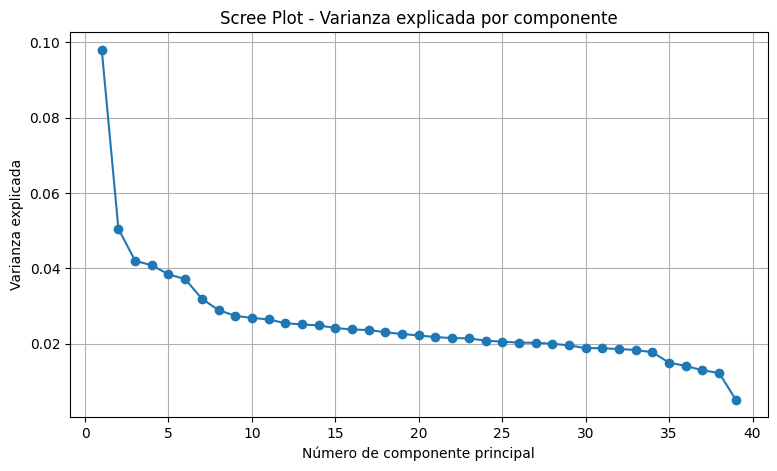

In [16]:
plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(varianza) + 1),
    varianza,
    marker="o"
)

plt.title("Scree Plot - Varianza explicada por componente")
plt.xlabel("Número de componente principal")
plt.ylabel("Varianza explicada")
plt.grid(True)
plt.show()

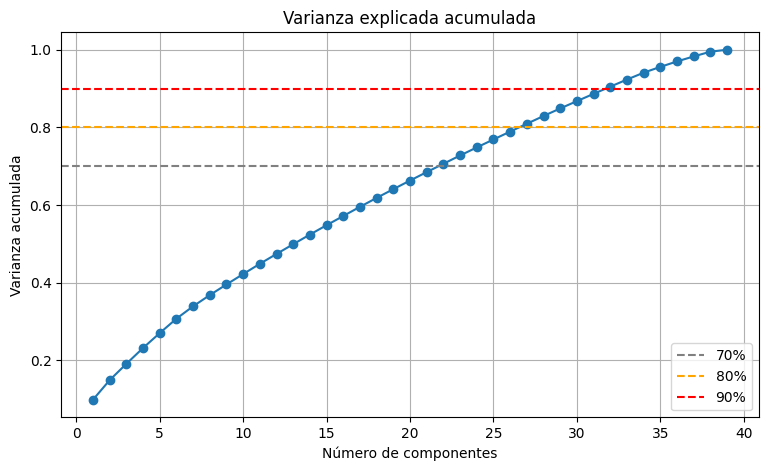

In [17]:
plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o"
)

plt.axhline(y=0.70, color="gray", linestyle="--", label="70%")
plt.axhline(y=0.80, color="orange", linestyle="--", label="80%")
plt.axhline(y=0.90, color="red", linestyle="--", label="90%")

plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Determinar cuántos componentes se necesitan para conservar cierto porcentaje de información

for porcentaje in [0.70, 0.80, 0.90]:
    n_componentes = np.argmax(varianza_acumulada >= porcentaje) + 1
    print(f"Componentes necesarios para conservar {porcentaje*100:.0f}% de varianza:", n_componentes)

Componentes necesarios para conservar 70% de varianza: 22
Componentes necesarios para conservar 80% de varianza: 27
Componentes necesarios para conservar 90% de varianza: 32


**9. PCA con 2 componentes para visualización**

In [19]:
# PCA con 2 componentes para graficar los datos
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print("Varianza explicada por PC1 y PC2:", pca_2.explained_variance_ratio_)
print("Varianza acumulada:", np.cumsum(pca_2.explained_variance_ratio_))

Varianza explicada por PC1 y PC2: [0.0980706  0.05049522]
Varianza acumulada: [0.0980706  0.14856582]


In [20]:
# Crear dataframe con componentes principales
df_pca = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"]
)

df_pca.head()

,PC1,PC2
0,-2.174747,-0.420241
1,-0.666022,-0.450510
2,3.521105,-2.458122
3,-2.031860,-0.588744
4,3.458192,0.106122


**10. Coeficientes de las variables en PCA**

In [21]:
# Coeficientes o cargas de las variables en los componentes principales

componentes = pd.DataFrame(
    pca_2.components_,
    columns=model_columns,
    index=["PC1", "PC2"]
)

componentes

,gradyear,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
PC1,0.097468,-0.089231,0.098298,0.151862,0.149471,0.091810,0.085934,0.083816,0.113274,0.10577,...,0.209373,0.181560,0.177748,0.226515,0.153715,0.158306,0.185706,0.131928,0.169281,0.211009
PC2,0.523864,-0.514716,0.128413,0.151850,0.085600,0.107889,0.119729,0.163650,0.073662,0.11417,...,-0.007845,0.096162,0.132875,-0.022554,0.155136,0.135760,-0.163046,-0.106000,-0.178066,-0.178749


In [22]:
# Variables con mayor influencia en PC1

print("Variables más importantes en PC1:")
componentes.loc["PC1"].abs().sort_values(ascending=False).head(10)

Variables más importantes en PC1:


,PC1
hair,0.325777
kissed,0.266129
sex,0.266098
clothes,0.226515
drugs,0.211009
music,0.209546
blonde,0.209373
cute,0.192007
rock,0.191295
die,0.185706


In [23]:
# Variables con mayor influencia en PC2

print("Variables más importantes en PC2:")
componentes.loc["PC2"].abs().sort_values(ascending=False).head(10)

Variables más importantes en PC2:


,PC2
gradyear,0.523864
age,0.514716
sex,0.214768
drugs,0.178749
drunk,0.178066
kissed,0.175322
volleyball,0.163650
die,0.163046
hollister,0.155136
band,0.153476


**11. Biplot para interpretar variables**

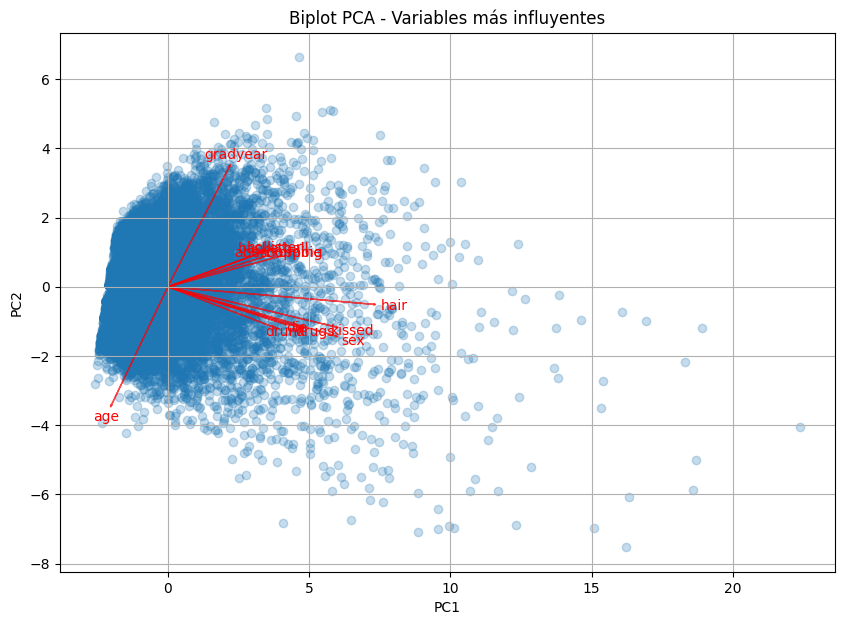

In [24]:
def biplot(score, coeff, labels=None, n_variables=12):
    xs = score[:, 0]
    ys = score[:, 1]

    plt.figure(figsize=(10,7))
    plt.scatter(xs, ys, alpha=0.25)

    # Seleccionar variables más importantes considerando PC1 y PC2
    importancia = np.abs(coeff[0]) + np.abs(coeff[1])
    indices = np.argsort(importancia)[-n_variables:]

    for i in indices:
        plt.arrow(
            0, 0,
            coeff[0, i] * max(xs),
            coeff[1, i] * max(ys),
            color="red",
            alpha=0.7,
            head_width=0.05
        )

        if labels is None:
            texto = f"Var{i+1}"
        else:
            texto = labels[i]

        plt.text(
            coeff[0, i] * max(xs) * 1.1,
            coeff[1, i] * max(ys) * 1.1,
            texto,
            color="red",
            ha="center",
            va="center"
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot PCA - Variables más influyentes")
    plt.grid(True)
    plt.show()

biplot(X_pca_2, pca_2.components_, labels=model_columns, n_variables=12)

# Aplicación de K-Means

**12. Método del codo y Silhouette Score**

In [25]:
# Evaluar diferentes valores de K

inertias = []
silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    # Se usa sample_size para que el cálculo no tarde demasiado
    sil_score = silhouette_score(
        X_scaled,
        clusters,
        sample_size=5000,
        random_state=42
    )

    silhouette_scores.append(sil_score)

# Crear tabla de resultados
metricas_k = pd.DataFrame({
    "K": list(K),
    "Inercia": inertias,
    "Silhouette Score": silhouette_scores
})

metricas_k

,K,Inercia,Silhouette Score
0,2,550771.119372,0.278342
1,3,532914.365175,0.151424
2,4,518394.208625,0.018371
3,5,503297.177069,0.046747
4,6,490389.602462,0.023025
5,7,479944.366780,0.019969
6,8,469254.730963,0.026300
7,9,460956.249950,0.019195
8,10,452630.441014,0.021755


**13. Gráfica del método del codo**

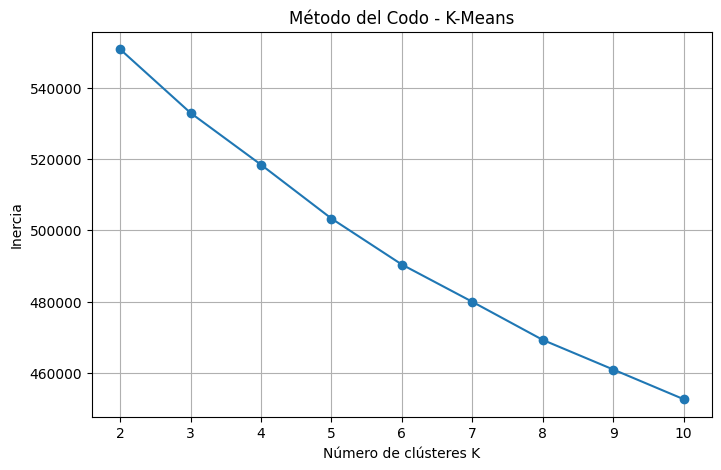

In [26]:
plt.figure(figsize=(8,5))
plt.plot(metricas_k["K"], metricas_k["Inercia"], marker="o")

plt.title("Método del Codo - K-Means")
plt.xlabel("Número de clústeres K")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

**14. Gráfica de Silhouette Score**

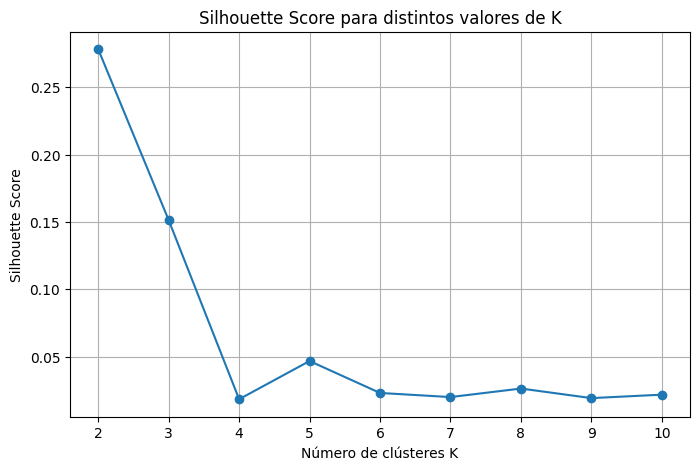

In [27]:
plt.figure(figsize=(8,5))
plt.plot(metricas_k["K"], metricas_k["Silhouette Score"], marker="o")

plt.title("Silhouette Score para distintos valores de K")
plt.xlabel("Número de clústeres K")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

**15. Selección del número de clústeres**

K = 5

In [28]:
# Seleccionar número de clusters
k_elegido = 5

# Entrenar modelo final
kmeans_final = KMeans(
    n_clusters=k_elegido,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_scaled)

# Agregar cluster al dataset original limpio
df["cluster"] = clusters

df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,cluster
0,2007,Unknown,17.281,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2007,F,17.410,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,1
2,2007,F,17.511,41,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,1,3
3,2006,F,17.281,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,3,0,0,0,0,0,0,3


# Visualización de Clústeres con PCA

**16. Agregar PC1 y PC2 al dataset**

In [29]:
df["PC1"] = X_pca_2[:, 0]
df["PC2"] = X_pca_2[:, 1]

df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,clothes,hollister,abercrombie,die,death,drunk,drugs,cluster,PC1,PC2
0,2007,Unknown,17.281,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,-2.174747,-0.420241
1,2007,F,17.410,49,0,0,1,0,0,1,...,0,0,0,0,0,1,0,1,-0.666022,-0.450510
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,0,0,0,0,1,1,3,3.521105,-2.458122
3,2006,F,17.281,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,-2.031860,-0.588744
4,2008,F,16.657,1,0,0,0,0,0,1,...,3,0,0,0,0,0,0,3,3.458192,0.106122


**17. Gráfico PCA con clústeres**

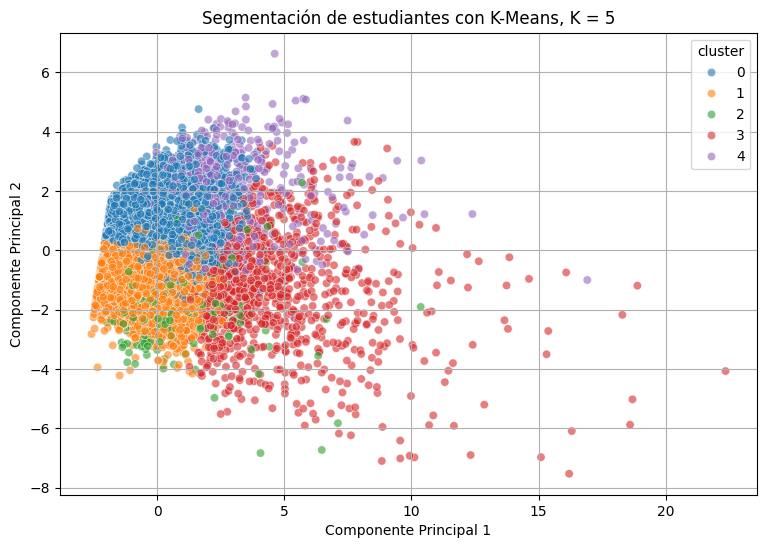

In [30]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title(f"Segmentación de estudiantes con K-Means, K = {k_elegido}")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

**18. Gráfico PCA con centroides**

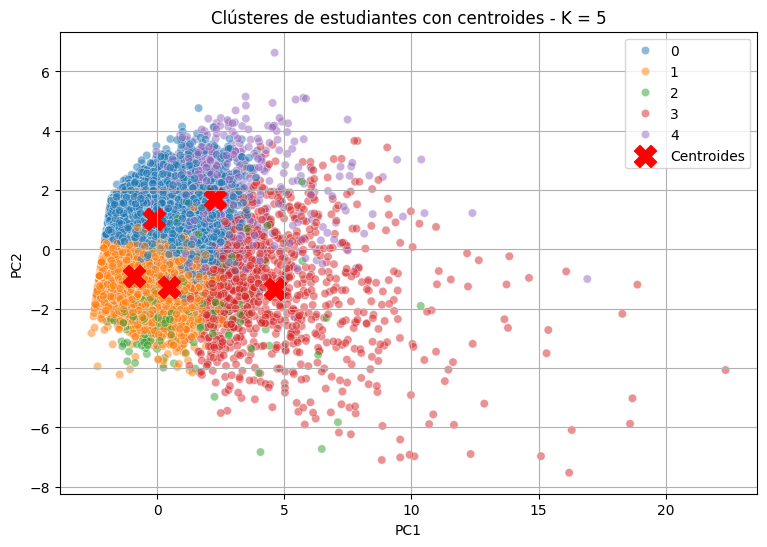

In [31]:
# Transformar centroides al espacio PCA
centroides_pca = pca_2.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.5
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    s=250,
    marker="X",
    color="red",
    label="Centroides"
)

plt.title(f"Clústeres de estudiantes con centroides - K = {k_elegido}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

**19. Visualización adicional PC3 vs PC4**

In [32]:
# PCA con 4 componentes para revisar PC3 y PC4
pca_4 = PCA(n_components=4)
X_pca_4 = pca_4.fit_transform(X_scaled)

df["PC3"] = X_pca_4[:, 2]
df["PC4"] = X_pca_4[:, 3]

print("Varianza explicada por PC1, PC2, PC3 y PC4:")
print(pca_4.explained_variance_ratio_)

Varianza explicada por PC1, PC2, PC3 y PC4:
[0.0980706  0.05049522 0.04201134 0.04080118]


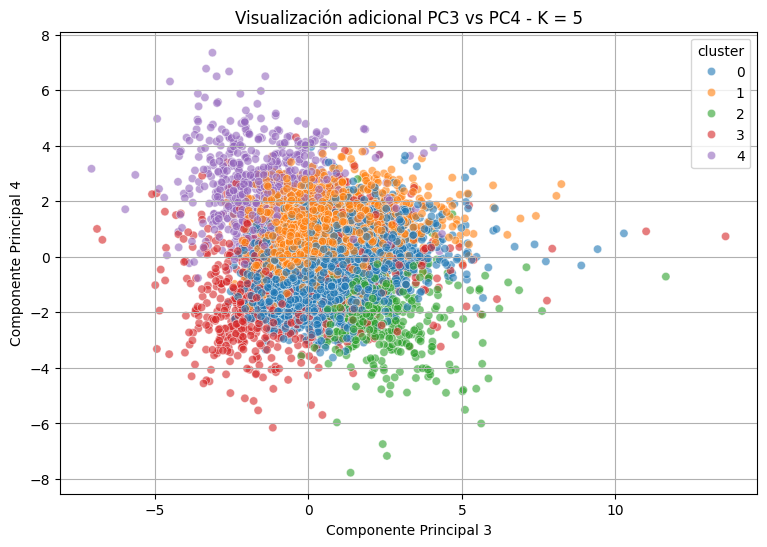

In [33]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="PC3",
    y="PC4",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title(f"Visualización adicional PC3 vs PC4 - K = {k_elegido}")
plt.xlabel("Componente Principal 3")
plt.ylabel("Componente Principal 4")
plt.grid(True)
plt.show()

# Análisis descriptivo de los clústeres

**20. Tamaño de cada clúster**

In [34]:
conteo_clusters = df["cluster"].value_counts().sort_index()

porcentaje_clusters = (conteo_clusters / len(df) * 100).round(2)

tabla_tamano_clusters = pd.DataFrame({
    "Cantidad de estudiantes": conteo_clusters,
    "Porcentaje": porcentaje_clusters
})

tabla_tamano_clusters

,Cantidad de estudiantes,Porcentaje
cluster,,
0,6320,42.13
1,6516,43.44
2,412,2.75
3,1045,6.97
4,707,4.71


**21. Promedios por clúster**

In [35]:
# Variables principales para interpretar clústeres

variables_interpretacion = [
    "age", "NumberOffriends",
    "basketball", "football", "soccer", "softball", "volleyball",
    "swimming", "cheerleading", "baseball", "tennis", "sports",
    "band", "marching", "music", "rock",
    "god", "church", "jesus", "bible",
    "mall", "shopping", "clothes", "hollister", "abercrombie",
    "die", "death", "drunk", "drugs"
]

resumen_clusters = df.groupby("cluster")[variables_interpretacion].mean().round(2)

resumen_clusters

,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,...,bible,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
cluster,,,,,,,,,,,,,,,,,,,,,
0,16.51,32.96,0.32,0.28,0.27,0.20,0.19,0.14,0.11,0.12,...,0.02,0.27,0.36,0.11,0.02,0.00,0.13,0.09,0.05,0.02
1,18.07,24.51,0.15,0.16,0.14,0.09,0.07,0.08,0.05,0.07,...,0.01,0.14,0.24,0.08,0.01,0.01,0.14,0.09,0.06,0.02
2,17.38,34.78,0.18,0.26,0.17,0.19,0.13,0.15,0.08,0.06,...,0.03,0.18,0.30,0.15,0.01,0.02,0.14,0.12,0.05,0.03
3,17.12,33.55,0.62,0.57,0.41,0.27,0.24,0.30,0.24,0.26,...,0.08,0.65,0.63,0.64,0.08,0.08,0.81,0.40,0.58,0.61
4,17.02,42.57,0.45,0.38,0.31,0.28,0.31,0.28,0.35,0.13,...,0.01,0.69,1.02,0.36,1.14,0.89,0.22,0.16,0.09,0.05


**22. Distribución de género por clúster**

In [36]:
# Aunque gender no se usó para entrenar K-Means, sí puede ayudar a interpretar

tabla_genero = pd.crosstab(
    df["cluster"],
    df["gender"],
    normalize="index"
).round(3)

tabla_genero

gender,F,M,Unknown
cluster,,,
0,0.759,0.159,0.082
1,0.685,0.209,0.106
2,0.757,0.189,0.053
3,0.837,0.107,0.056
4,0.863,0.066,0.071


**23. Promedios por categoría de variables**

In [37]:
# creamos resumen por categorías para facilitar interpretación

resumen_categorias = pd.DataFrame()

resumen_categorias["Promedio amigos"] = df.groupby("cluster")["NumberOffriends"].mean()

resumen_categorias["Deportes"] = df.groupby("cluster")[variables_deportes].mean().mean(axis=1)

resumen_categorias["Música"] = df.groupby("cluster")[variables_musica].mean().mean(axis=1)

resumen_categorias["Religión"] = df.groupby("cluster")[variables_religion].mean().mean(axis=1)

resumen_categorias["Moda / Social"] = df.groupby("cluster")[variables_moda_social].mean().mean(axis=1)

resumen_categorias["Riesgo"] = df.groupby("cluster")[variables_riesgo].mean().mean(axis=1)

resumen_categorias.round(2)

,Promedio amigos,Deportes,Música,Religión,Moda / Social,Riesgo
cluster,,,,,,
0,32.96,0.19,0.27,0.20,0.17,0.07
1,24.51,0.10,0.23,0.17,0.11,0.08
2,34.78,0.15,1.57,0.24,0.18,0.08
3,33.55,0.35,0.82,0.49,0.82,0.60
4,42.57,0.28,0.35,0.27,0.54,0.13


**24. Gráfico de categorías por clúster**

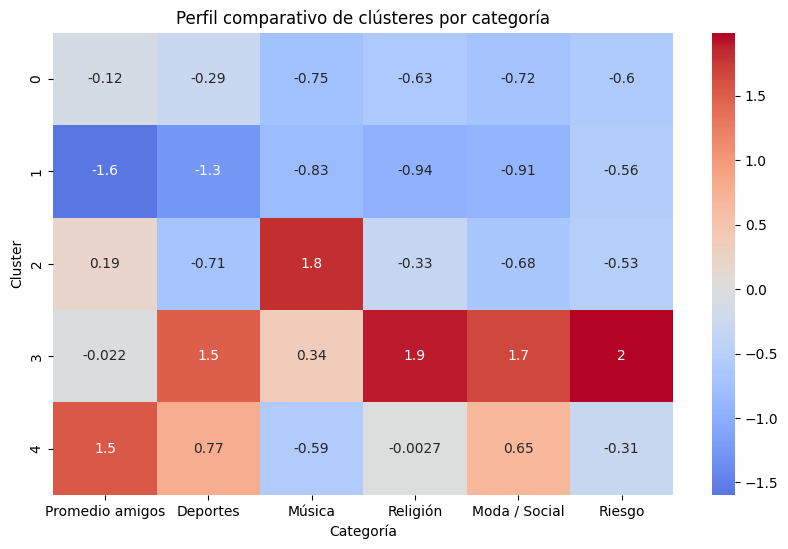

In [38]:
resumen_categorias_plot = resumen_categorias.copy()

# Escalamos solo para visualizar mejor las diferencias entre categorías
scaler_categorias = StandardScaler()
resumen_categorias_scaled = pd.DataFrame(
    scaler_categorias.fit_transform(resumen_categorias_plot),
    columns=resumen_categorias_plot.columns,
    index=resumen_categorias_plot.index
)

plt.figure(figsize=(10,6))

sns.heatmap(
    resumen_categorias_scaled,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Perfil comparativo de clústeres por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cluster")
plt.show()

**25. Variables dominantes por clúster**

In [39]:
# para identificar que variables destacan más en cada cluster
# Se compara el promedio del cluster contra el promedio global

variables_perfil = (
    variables_deportes +
    variables_musica +
    variables_religion +
    variables_moda_social +
    variables_riesgo
)

promedio_global = df[variables_perfil].mean()
promedio_cluster = df.groupby("cluster")[variables_perfil].mean()

for cluster in sorted(df["cluster"].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 40)

    diferencia_relativa = (
        (promedio_cluster.loc[cluster] + 0.01) /
        (promedio_global + 0.01)
    )

    print("Variables más representativas:")
    print(diferencia_relativa.sort_values(ascending=False).head(10).round(2))


Cluster 0
----------------------------------------
Variables más representativas:
volleyball    1.30
softball      1.26
soccer        1.19
basketball    1.18
hot           1.15
baseball      1.12
football      1.10
swimming      1.07
church        1.06
mall          1.06
dtype: float64

Cluster 1
----------------------------------------
Variables más representativas:
dress     0.93
tennis    0.89
god       0.83
music     0.81
bible     0.80
jesus     0.79
death     0.79
die       0.77
church    0.76
drunk     0.70
dtype: float64

Cluster 2
----------------------------------------
Variables más representativas:
marching    28.50
band        10.82
tennis       1.49
music        1.47
rock         1.43
dress        1.25
jesus        1.19
bible        1.19
softball     1.19
dance        1.17
dtype: float64

Cluster 3
----------------------------------------
Variables más representativas:
kissed     9.22
drugs      8.72
sex        8.25
blonde     7.25
drunk      5.80
hair       5.61
die    

# Interpretación de perfiles

**26. Asignar nombres a los clústeres**

In [40]:
nombres_clusters = {
    0: "Estudiantes con actividad social/deportiva moderada",
    1: "Estudiantes con baja actividad en intereses publicados",
    2: "Estudiantes orientados a música/banda",
    3: "Estudiantes con menciones de riesgo y alta actividad social",
    4: "Estudiantes orientados a moda, shopping y socialización"
}

df["perfil_cluster"] = df["cluster"].map(nombres_clusters)

df[["cluster", "perfil_cluster"]].head()

,cluster,perfil_cluster
0,1,Estudiantes con baja actividad en intereses pu...
1,1,Estudiantes con baja actividad en intereses pu...
2,3,Estudiantes con menciones de riesgo y alta act...
3,1,Estudiantes con baja actividad en intereses pu...
4,3,Estudiantes con menciones de riesgo y alta act...


**27. Tabla final de perfiles**

In [41]:
tabla_perfiles = df.groupby(["cluster", "perfil_cluster"])[
    ["age", "NumberOffriends"]
].mean().round(2)

tabla_perfiles

,,age,NumberOffriends
cluster,perfil_cluster,,
0,Estudiantes con actividad social/deportiva moderada,16.51,32.96
1,Estudiantes con baja actividad en intereses publicados,18.07,24.51
2,Estudiantes orientados a música/banda,17.38,34.78
3,Estudiantes con menciones de riesgo y alta actividad social,17.12,33.55
4,"Estudiantes orientados a moda, shopping y socialización",17.02,42.57


**28. Interpretación automática por clúster**

In [42]:
for cluster in sorted(df["cluster"].unique()):
    print(f"\nCLUSTER {cluster}: {nombres_clusters.get(cluster, 'Sin nombre')}")
    print("-" * 70)

    cantidad = df[df["cluster"] == cluster].shape[0]
    porcentaje = cantidad / len(df) * 100

    print(f"Cantidad de estudiantes: {cantidad}")
    print(f"Porcentaje del dataset: {porcentaje:.2f}%")
    print(f"Edad promedio: {df[df['cluster'] == cluster]['age'].mean():.2f}")
    print(f"Promedio de amigos: {df[df['cluster'] == cluster]['NumberOffriends'].mean():.2f}")

    print("\nCategorías promedio:")
    print(resumen_categorias.loc[cluster].round(2))

    print("\nVariables dominantes:")
    diferencia_relativa = (
        (promedio_cluster.loc[cluster] + 0.01) /
        (promedio_global + 0.01)
    )
    print(diferencia_relativa.sort_values(ascending=False).head(8).round(2))


CLUSTER 0: Estudiantes con actividad social/deportiva moderada
----------------------------------------------------------------------
Cantidad de estudiantes: 6320
Porcentaje del dataset: 42.13%
Edad promedio: 16.51
Promedio de amigos: 32.96

Categorías promedio:
Promedio amigos    32.96
Deportes            0.19
Música              0.27
Religión            0.20
Moda / Social       0.17
Riesgo              0.07
Name: 0, dtype: float64

Variables dominantes:
volleyball    1.30
softball      1.26
soccer        1.19
basketball    1.18
hot           1.15
baseball      1.12
football      1.10
swimming      1.07
dtype: float64

CLUSTER 1: Estudiantes con baja actividad en intereses publicados
----------------------------------------------------------------------
Cantidad de estudiantes: 6516
Porcentaje del dataset: 43.44%
Edad promedio: 18.07
Promedio de amigos: 24.51

Categorías promedio:
Promedio amigos    24.51
Deportes            0.10
Música              0.23
Religión            0.17
Mod

# Conclusiones y recomendaciones

A partir del análisis realizado con K-Means, se logró segmentar a los estudiantes
en grupos con características similares de acuerdo con su actividad en redes sociales,
intereses, número de amigos y menciones relacionadas con deportes, música, religión,
moda, socialización y riesgo.

El uso de PCA permitió reducir la dimensionalidad del dataset y visualizar los clústeres
en un espacio de dos componentes principales. Aunque la separación no siempre es perfecta,
los grupos encontrados permiten identificar perfiles útiles para análisis social,
bienestar estudiantil y estrategias de comunicación universitaria.

La tabla de inercia y Silhouette Score permitió comparar distintos valores de K.
El valor seleccionado de K debe justificarse tanto por las métricas como por la
interpretabilidad de los perfiles obtenidos.

# Recomendaciones

1. Para los estudiantes con alto interés deportivo, se recomienda promover actividades
   físicas, torneos universitarios, clubes deportivos y campañas de integración.

2. Para los estudiantes con intereses en moda, shopping y socialización, pueden diseñarse
   campañas visuales, eventos sociales, ferias estudiantiles o actividades de convivencia.

3. Para los estudiantes con menciones relacionadas con música o banda, se pueden impulsar
   clubes artísticos, presentaciones musicales, grupos culturales o actividades extracurriculares.

4. Para los estudiantes con menciones de riesgo como drunk, drugs, die o death, se recomienda
   diseñar campañas de bienestar emocional, prevención de adicciones y acompañamiento psicológico.

5. Para los estudiantes con menor actividad o menos amigos, se pueden crear estrategias de
   integración, tutorías, grupos de apoyo o actividades que fomenten la participación social.